In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vivarium import Artifact

!date

Wed Oct  8 21:22:15 PDT 2025


/home/abie/miniforge3/envs/vivarium_nih_moud_simulation/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [35]:
!ls -halt washington.hdf  # expects this to be in root directory of repo

-rw-r--r-- 1 abie abie 76M Oct  8 20:49 washington.hdf


In [36]:
%run src/vivarium_nih_moud/data/dismod_at.py

sample: 100%|██████████| 2000/2000 [11:35<00:00,  2.88it/s, 511 steps of size 7.67e-03. acc. prob=0.84] 


In [37]:
art = Artifact(path='washington.hdf')

In [38]:
def art_etl(key):
    data = art.load(key)
    data = (data.apply(pd.DataFrame.describe, percentiles=[0.025, 0.975], axis=1)
            .filter(['mean', '2.5%', '97.5%']).reset_index())
    data = data[data.age_end <= 95]
    return data

In [39]:
def age_group_plot(measure, art_old, art_new):
    fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(12, 5))
    for j, sex in enumerate(art_new.sex.unique()):
        for i, art_data in enumerate([art_old, art_new]):
            color = f'C{i}'
            if i == 0:
                linestyle = '--'
                label='Old'
            else:
                linestyle = '-'
                label='New'

            art_plot = art_data.loc[(art_data.sex == sex)]

            ax[j].fill_between(art_plot.age_start, art_plot['2.5%'], art_plot['97.5%'], alpha=0.2, color=color)
            ax[j].plot(art_plot.age_start, art_plot['mean'], linestyle=linestyle, label=label, color=color, linewidth=3)


        ax[j].text(.5, .95, f"{sex}", va='top', ha='center', transform=ax[j].transAxes)
        ax[j].set_xlabel("Age (years)")

        if j == 0:
            ax[j].set_ylabel(f"{measure}")
        if j == 1:
            ax[j].legend(loc=(1.01, 0))

        plt.subplots_adjust(wspace=0)

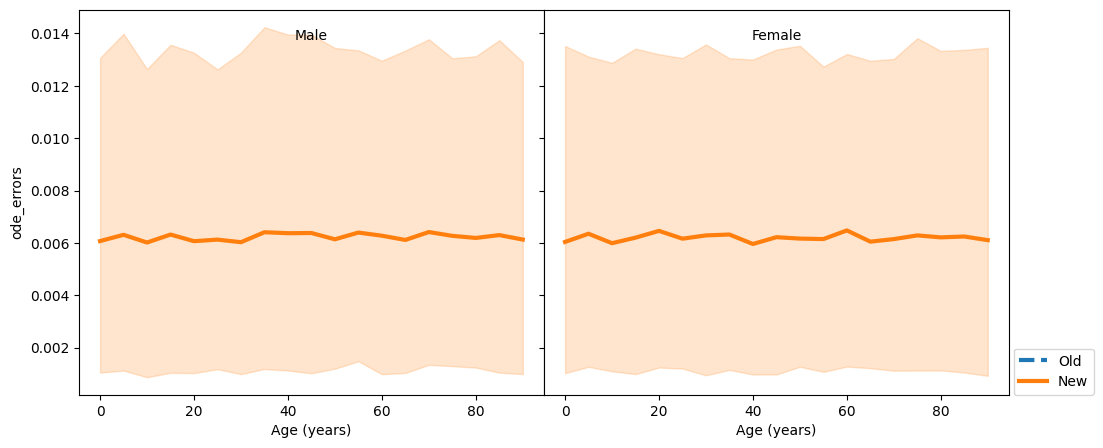

In [40]:
# Plot ODE errors (if available)
try:
    df_new = art_etl('cause.oud_consistent.ode_errors')
    df_old = df_new.iloc[[], :]
    age_group_plot('ode_errors', df_old, df_new)
except Exception as e:
    print(f'ODE errors not available: {e}')

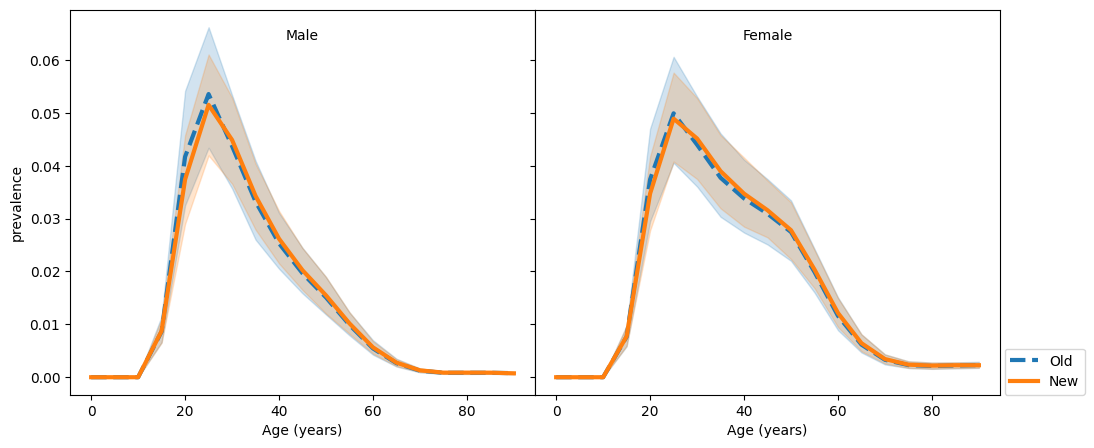

In [41]:
# Plot prevalence
df_old = art_etl('cause.opioid_use_disorders.prevalence')
df_new = art_etl('cause.oud_consistent.prevalence')
age_group_plot('prevalence', df_old, df_new)

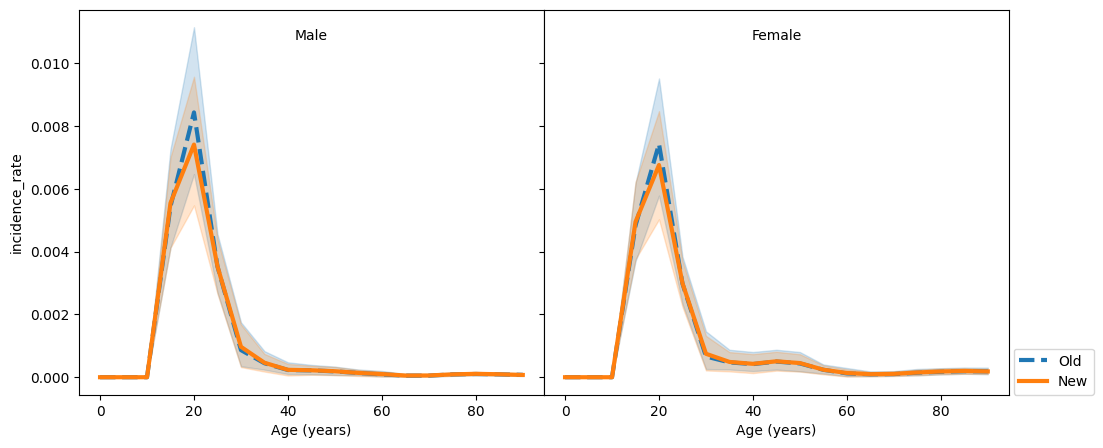

In [42]:
# Plot incidence rate
df_old = art_etl('cause.opioid_use_disorders.incidence_rate')
df_new = art_etl('cause.oud_consistent.incidence_rate')
age_group_plot('incidence_rate', df_old, df_new)

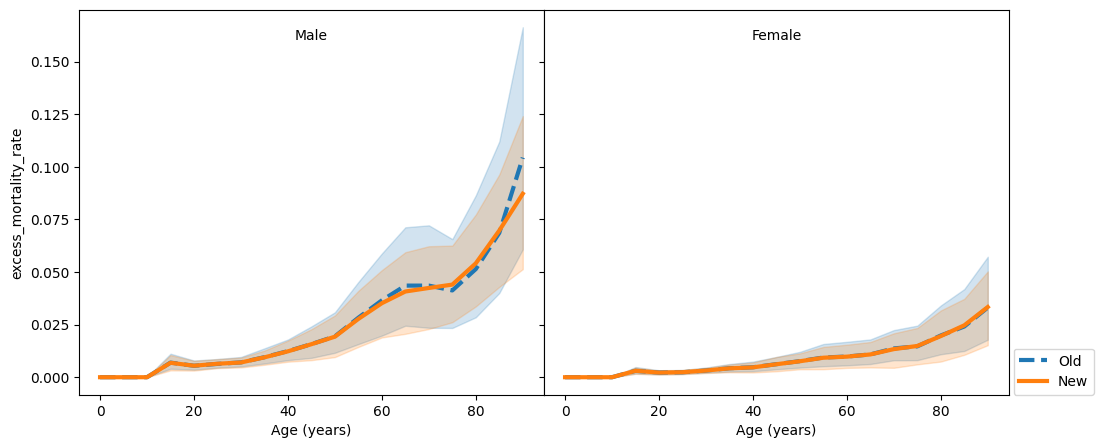

In [43]:
# Plot excess mortality rate
df_old = art_etl('cause.opioid_use_disorders.excess_mortality_rate')
df_new = art_etl('cause.oud_consistent.excess_mortality_rate')
age_group_plot('excess_mortality_rate', df_old, df_new)

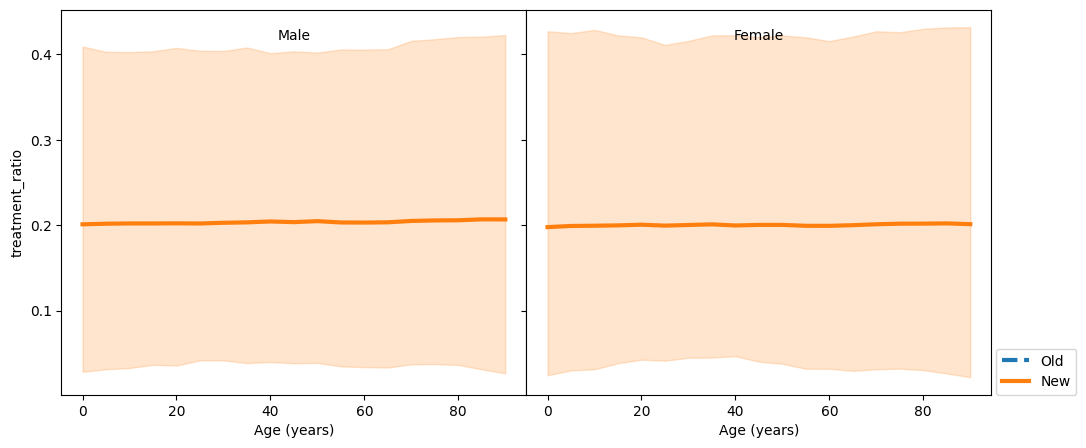

In [44]:
# Plot treatment ratio (only consistent version exists)
df_new = art_etl('cause.oud_consistent.treatment_ratio')
df_old = df_new.iloc[[], :]  # Empty dataframe for comparison
age_group_plot('treatment_ratio', df_old, df_new)

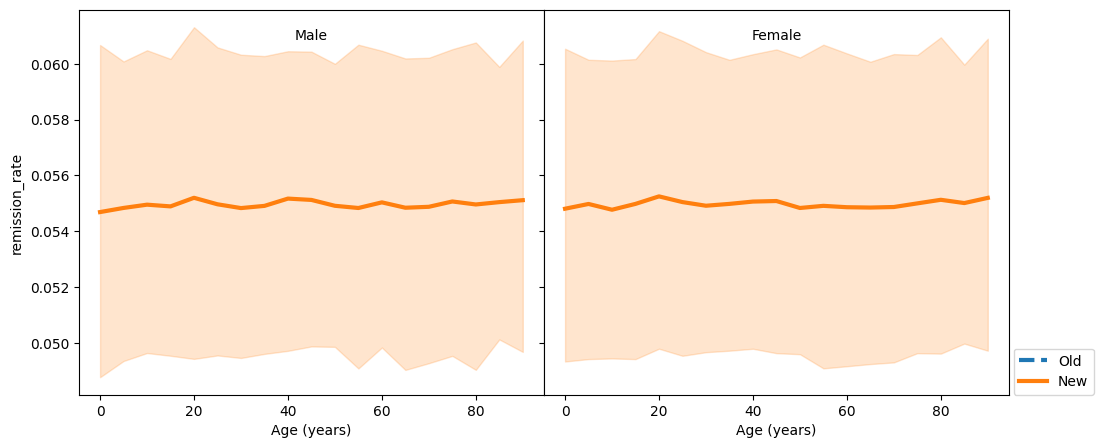

In [45]:
# Plot remission rate (only consistent version exists)
df_new = art_etl('cause.oud_consistent.remission_rate')
df_old = df_new.iloc[[], :]  # Empty dataframe for comparison
age_group_plot('remission_rate', df_old, df_new)

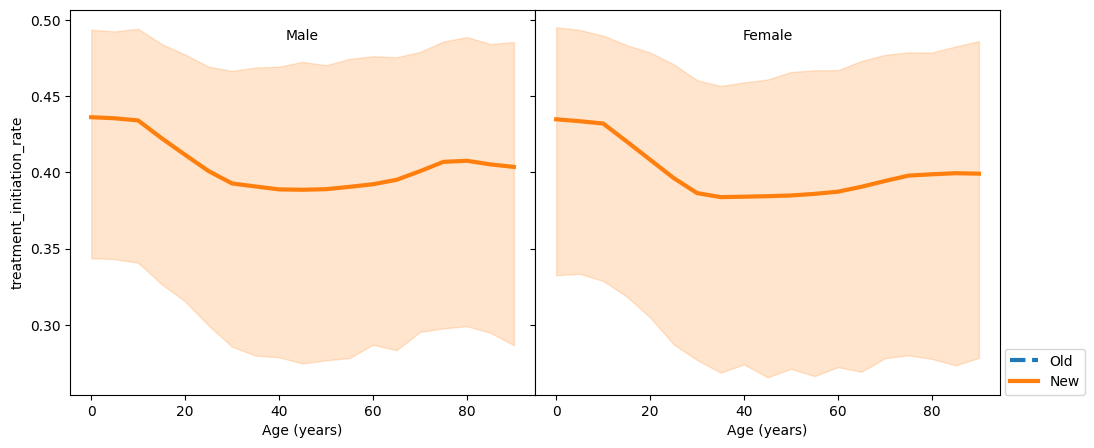

In [46]:
# Plot treatment initiation rate (only consistent version exists)
df_new = art_etl('cause.oud_consistent.treatment_initiation_rate')
df_old = df_new.iloc[[], :]  # Empty dataframe for comparison
age_group_plot('treatment_initiation_rate', df_old, df_new)

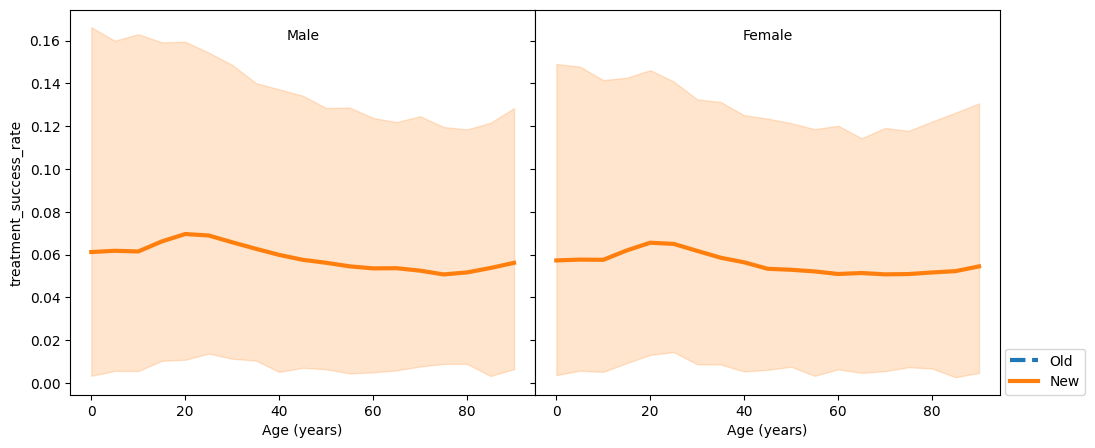

In [47]:
# Plot treatment success rate (only consistent version exists)
df_new = art_etl('cause.oud_consistent.treatment_success_rate')
df_old = df_new.iloc[[], :]  # Empty dataframe for comparison
age_group_plot('treatment_success_rate', df_old, df_new)

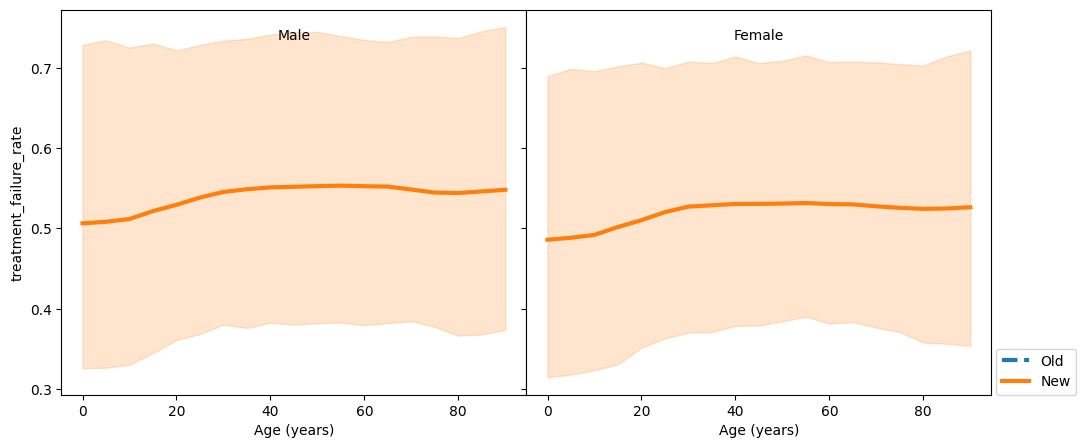

In [48]:
# Plot treatment failure rate (only consistent version exists)
df_new = art_etl('cause.oud_consistent.treatment_failure_rate')
df_old = df_new.iloc[[], :]  # Empty dataframe for comparison
age_group_plot('treatment_failure_rate', df_old, df_new)

Text(0.5, 1.0, 'Treatment Ratio Sample Draws (Male=orange, Female=blue)')

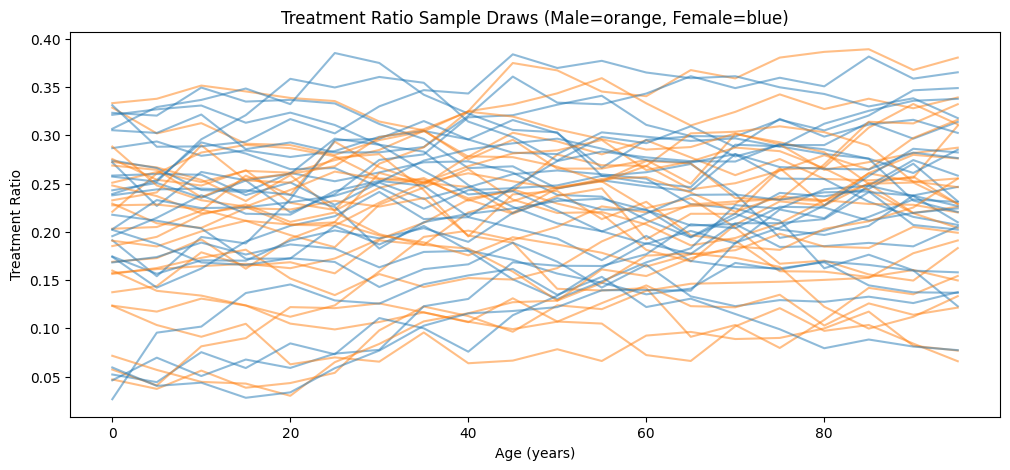

In [49]:
# Visualize sample variation in treatment ratio across age
t = art.load('cause.oud_consistent.treatment_ratio')
plt.figure(figsize=(12, 5))
for col in t.filter(like='draw_').columns[:25]:
    plt.plot(t[col].unstack(level=0).reset_index().set_index('age_start').Male, color='C1', alpha=.5)
    plt.plot(t[col].unstack(level=0).reset_index().set_index('age_start').Female, color='C0', alpha=.5)
plt.xlabel('Age (years)')
plt.ylabel('Treatment Ratio')
plt.title('Treatment Ratio Sample Draws (Male=orange, Female=blue)')